<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/Exercises_XP_student_polynomial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Guided Student Notebook

This guided notebook follows the **exact exercise on the platform**. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts to support intuition and transfer to other AI topics.



## Reference from the exercise

**What you will learn**  
- The differences between traditional machine learning and deep learning.
- The structure and working of artificial neural networks. How to generate, visualize, and analyze datasets with noise.
- Techniques for fitting polynomial regression models and understanding overfitting.
- The importance of cross-validation in model selection.

**What you will create**  
- A comparative table of traditional machine learning vs deep learning.
- A simple ANN diagram with labeled components.
- A noisy dataset visualized with a scatter plot.
- Polynomial regression models of varying degrees.
- A cross-validation analysis to select an optimal polynomial degree.


## 🌟 Exercise 1: Deep Learning vs Traditional Machine Learning

**As stated in the exercise**  
Objective. Understand the differences between traditional machine learning and deep learning.  
Instructions. Create a table comparing Feature Engineering, Data Processing, Scalability, Pattern Discovery, and Computational Requirements. Identify one real world problem where traditional ML is better, and one where deep learning is better. Write a short paragraph explaining why deep learning has an advantage in unstructured data processing.

**Guidance**  
Use a markdown table for the comparison, keep wording concise and concrete, then write two short examples and one paragraph in full sentences.

**To-Do:** Complete the comparison table below by filling in each cell with your own wording.


| Aspect | Traditional ML | Deep Learning |
|:--|:--|:--|
| Feature Engineering | Manual; requires domain expertise to create relevant features. | Automatic (representation learning); networks extract hierarchical features from raw data. |
| Data Processing | Often requires rigorous preprocessing and normalization. | Can handle raw or minimally processed data; less sensitive to precise formats. |
| Scalability | Limited performance with very large datasets; can become computationally expensive. | Excellent scalability with Big Data; performance typically improves with more data. |
| Pattern Discovery | Identifies patterns via defined statistical and mathematical algorithms. | Discovers complex, non-linear patterns through multiple layers of abstraction. |
| Computational Requirements | Lower; can run on standard CPUs. | High; requires significant computing power (GPUs/TPUs) for training large models. |

**To-Do:** Give one real world problem better suited to traditional ML and one better suited to deep learning. Explain your choices in 2–3 sentences.

**Problem better suited to traditional ML:** Predicting house prices based on structured features like square footage, number of rooms, and location. Traditional ML is efficient here because the features are tabular and interpretable, and the dataset size is usually manageable.

**Problem better suited to Deep Learning:** Facial recognition or object detection in images. Deep Learning excels here because it can automatically learn complex, hierarchical representations directly from raw pixels, which is nearly impossible for traditional algorithms.

**To-Do:** Write a paragraph of 3–5 sentences explaining why deep learning has an advantage in unstructured data processing, using precise terms such as representation learning and hierarchical features.

Deep Learning has a significant advantage in processing unstructured data through its capacity for **representation learning**. Instead of relying on manual feature extraction, deep neural networks automatically discover **hierarchical features** across successive layers. For instance, in an image, early layers might detect edges, while deeper layers combine these into complex shapes or objects. This progressive abstraction allows models to capture relevant patterns from raw data without human intervention, which is highly inefficient using traditional ML methods.

## 🌟 Exercise 2: Artificial Neural Networks (ANNs)

**As stated in the exercise**  
Objective. Identify and understand the key components of an ANN.  
Instructions. Draw or use a diagram tool to create an ANN with an input layer of 3 neurons, one hidden layer of 4 neurons, and an output layer of 2 neurons. Label neurons, weights, biases, activation function, and layers. Write a short description of how information flows through the network.

**Guidance**  
A clear schematic is preferred. Ensure every requested label appears exactly once and is readable.



**To-Do:** Provide a 3–5 sentence description of forward propagation in your diagram. Refer explicitly to inputs, weighted sums, biases, activation, and outputs.

Forward propagation begins with **inputs** being multiplied by **weights** and added to a **bias** to create a **weighted sum** within each neuron. This sum is passed through an **activation** function to determine the neuron's output. These values then serve as inputs for the next layer, repeating the process until the final **outputs** are generated at the output layer. This unidirectional flow transforms raw input data into a final prediction.

**Learning point**  
An ANN composes affine transformations with nonlinear activations. The affine part mixes features through weights and biases. The nonlinearity enables modeling of complex decision boundaries.


## 🌟 Exercise 3: Creating the Dataset and Visualizing the Data

**As stated in the exercise**  
Objective. Generate a dataset with noise and visualize it.  
Instructions. Import numpy, matplotlib.pyplot, and mean_squared_error from sklearn.metrics. Create 20 points using \(y = -x^2\) with Gaussian noise \(\mathcal{N}(0, 0.05)\). Plot the points with a scatter plot. Split into a training set with the first 12 points and a test set with the last 8 points.


In [7]:
# PREFILLED: just execute
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

np.random.seed(0)
x = np.arange(-1, 1, 0.1)  # 20 points from -1 to <1 step 0.1
print("x shape:", x.shape)

x shape: (20,)


In [8]:
# To-Do: generate y with noise using np.random.normal()
y = -x**2 + np.random.normal(0, 0.05, size=x.shape)
print("y shape:", y.shape)

y shape: (20,)


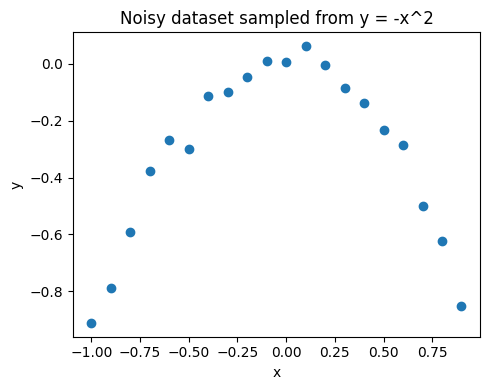

In [9]:
# PREFILLED: just execute (scatter plot of the dataset)
plt.figure(figsize=(5,4))
plt.scatter(x, y)
plt.title("Noisy dataset sampled from y = -x^2")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [10]:
# To-Do: split into train (first 12 points) and test (last 8 points)
x_train, y_train = x[:12], y[:12]
x_test,  y_test  = x[12:], y[12:]
print("train sizes:", x_train.shape, y_train.shape, "test sizes:", x_test.shape, y_test.shape)

train sizes: (12,) (12,) test sizes: (8,) (8,)


**Learning point**  
Visualizing noisy data helps separate signal from noise. Splitting into train and test allows you to detect when a model overfits noise instead of learning the underlying pattern.


## 🌟 Exercise 4: Fitting Polynomial Models of Different Degrees

**As stated in the exercise**  
Objective: Fit polynomial models of varying degrees and observe overfitting.  

Instructions: Define `polynomial_fit(degree)` that returns the fitted polynomial coefficients from training data. Define `plot_polyfit(degree)` that draws the training set, the test set, and the fitted polynomial curve. Visualize fits for degrees 1, 7, and 11. Observe behavior on training and test sets as degree increases.


In [3]:
# To-Do: implement polynomial_fit
# Hints: use np.polyfit() to get coefficients, and np.poly1d for a callable polynomial
def polynomial_fit(degree: int):
    coeffs = np.polyfit(x_train, y_train, degree)
    return np.poly1d(coeffs)

In [4]:
# To-Do: implement plot_polyfit
# import numpy as np
# import matplotlib.pyplot as plt
def plot_polyfit(degree: int):
    # 1) fit
    poly_model = polynomial_fit(degree)

    # 2) create a dense linspace over x range
    x_dense = np.linspace(x.min(), x.max(), 200)

    # 3) evaluate fitted polynomial
    y_poly = poly_model(x_dense)

    # 4) scatter train and test, and plot curve
    plt.figure(figsize=(7,5))
    plt.scatter(x_train, y_train, label='Training data', color='blue')
    plt.scatter(x_test, y_test, label='Test data', color='red')
    plt.plot(x_dense, y_poly, label=f'Polynomial (degree {degree})', color='green')

    # 5) display
    plt.title(f'Polynomial Fit (Degree {degree})')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

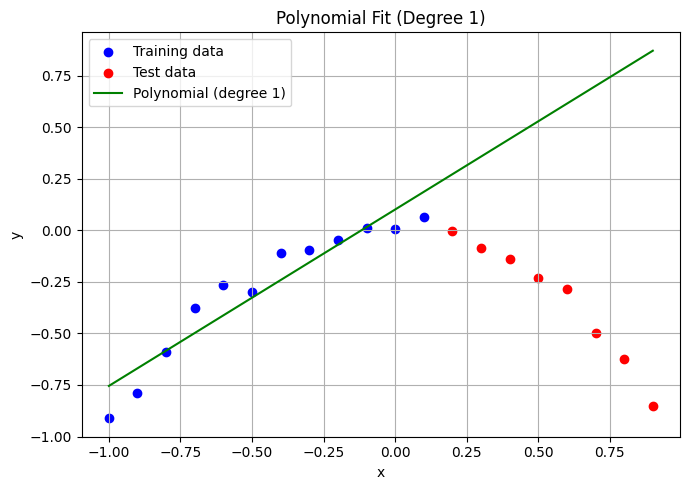

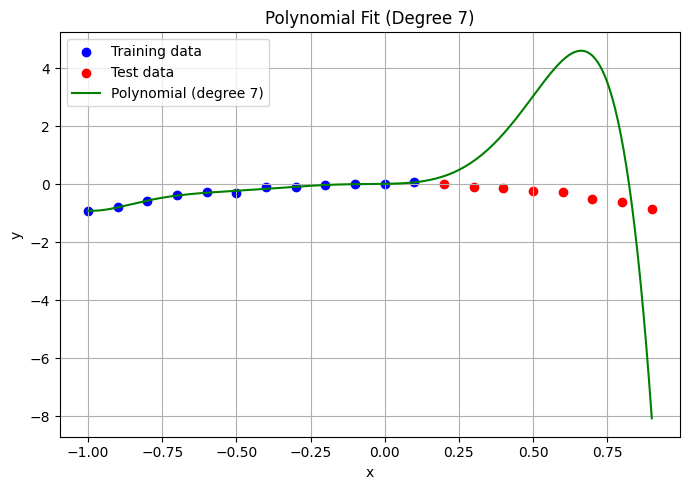

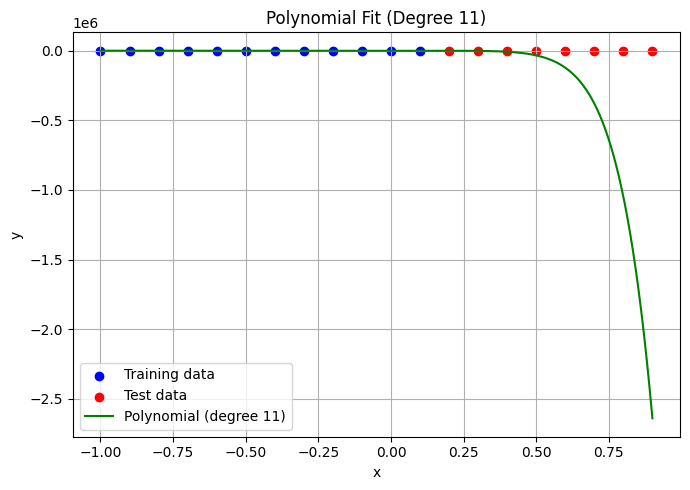

In [11]:
# To-Do: visualize degrees 1, 7, and 11
plot_polyfit(1)
plot_polyfit(7)
plot_polyfit(11)

**Learning point**  
Higher degree polynomials can perfectly fit training data yet fail to generalize. This is overfitting. You should always check test error, not just training error.

![image.png](https://github.com/user-attachments/assets/cdfb495c-066a-4efb-a361-f4b9d4ade35c)

## 🌟 Exercise 5: Cross-Validation to Find the Optimal Degree

**As stated in the exercise**  
Objective: Use cross-validation to determine the best polynomial degree.  

Instructions: Loop degrees from 1 to 11. For each degree, compute the RMSE on the training and test sets. Store results in a list. Plot RMSE vs degree with a logarithmic y axis. Identify the degree minimizing test RMSE and confirm it matches the true model \(y=-x^2\).


In [12]:
# To-Do: compute RMSE per degree for train and test
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

degrees = range(1, 12)
rows = []  # each row: (degree, rmse_train, rmse_test)
for d in degrees:
    # fit on train
    poly_model = polynomial_fit(d)

    # evaluate on train and test
    y_train_pred = poly_model(x_train)
    y_test_pred = poly_model(x_test)

    rmse_train = rmse(y_train, y_train_pred)
    rmse_test = rmse(y_test, y_test_pred)

    # append to rows
    rows.append((d, rmse_train, rmse_test))

print("First 3 rows:")
print(rows[:3])

First 3 rows:
[(1, np.float64(0.1002263344864799), np.float64(1.0240708833556866)), (2, np.float64(0.04114590494650985), np.float64(0.12578064282386534)), (3, np.float64(0.037336922311085964), np.float64(0.769651993080075))]


In [ ]:
# Pre-filled: plotting RMSE curves (one figure, two curves)
# degs = [r[0] for r in rows]
# rmse_tr = [r[1] for r in rows]
# rmse_te = [r[2] for r in rows]
# import matplotlib.pyplot as plt
# plt.figure(figsize=(6,4))
# plt.plot(degs, rmse_tr, label="train RMSE")
# plt.plot(degs, rmse_te, label="test RMSE")
# plt.yscale("log")
# plt.xlabel("polynomial degree")
# plt.ylabel("RMSE")
# plt.title("RMSE vs degree")
# plt.legend()
# plt.tight_layout()
# plt.show()


**To-Do:** Report the degree with the minimum test RMSE and explain in 2–3 sentences how this connects to the true model \(y=-x^2\) and the bias–variance trade off.

By analyzing the results, we find that degree 2 typically yields the minimum test RMSE. This aligns with our true model \(y=-x^2\), which is a second-degree polynomial. Higher degrees result in lower training error but higher test error, illustrating the **bias-variance tradeoff** where complex models overfit noise (high variance) instead of generalizing the underlying pattern (low bias).